# Problem 1

This notebook provides code to:
- Plot the feasible set \(S = \{(y_1,y_2): y_1^2 + \tfrac{1}{3}y_2^2 \le 1,\ y_1 \ge \tfrac{1}{2}\}\)
- Verify that the given piecewise \(f(x_1,x_2)\) equals the value function \(\max_{(y_1,y_2)\in S} x_1y_1 + x_2y_2\)
- Visualize the optimizer \(y^*(x)\)
 

(Utilities are in the next **code** cell.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def f_piecewise(x1, x2):
    """Piecewise f(x1,x2) given in the prompt."""
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    return np.where(
        np.abs(x2) <= x1,
        np.sqrt(x1**2 + 3 * x2**2),
        (x1 + 3 * np.abs(x2)) / 2,
    )


def y_star(x1, x2, eps=1e-12):
    """Argmax y*(x) for: max x1*y1 + x2*y2 over S.

    S = { (y1,y2): y1^2 + (1/3) y2^2 <= 1,  y1 >= 1/2 }.
    Returns (y1*, y2*).
    """
    x1 = float(x1)
    x2 = float(x2)

    denom = np.sqrt(x1**2 + 3 * x2**2)
    if denom < eps:
        return 0.5, 0.0

    # Unconstrained (ellipse-only) maximizer
    y1_unc = x1 / denom
    y2_unc = 3 * x2 / denom

    if y1_unc >= 0.5:
        return y1_unc, y2_unc

    # Constraint binds: y1=1/2, |y2|<=3/2
    return 0.5, (1.5 * np.sign(x2) if x2 != 0 else 0.0)


def f_value_from_max(x1, x2):
    """Value function computed from y*(x)."""
    y1, y2 = y_star(x1, x2)
    return x1 * y1 + x2 * y2


def plot_S(n=600):
    """Plot feasible region S in (y1,y2)."""
    y1 = np.linspace(-1, 1, n)
    y2 = np.sqrt(np.maximum(0.0, 3 * (1 - y1**2)))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(y1, y2, color="black", lw=2)
    ax.plot(y1, -y2, color="black", lw=2, label=r"$y_1^2+\frac{1}{3}y_2^2=1$")

    y1_fill = np.linspace(0.5, 1.0, n)
    y2_fill = np.sqrt(np.maximum(0.0, 3 * (1 - y1_fill**2)))
    ax.fill_between(y1_fill, -y2_fill, y2_fill, alpha=0.25, label=r"Feasible $S$")

    ax.axvline(0.5, color="tab:red", ls="--", lw=2, label=r"$y_1=\frac{1}{2}$")
    ax.set_xlabel(r"$y_1$")
    ax.set_ylabel(r"$y_2$")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend()
    ax.set_title("Feasible set S")
    plt.show()


def verify_on_grid(x1_range=(-2, 2), x2_range=(-2, 2), m=201):
    """Numerically verify f_piecewise == value function on a grid."""
    x1s = np.linspace(*x1_range, m)
    x2s = np.linspace(*x2_range, m)

    max_abs_err = 0.0
    worst = None
    for x1 in x1s:
        for x2 in x2s:
            fp = float(f_piecewise(x1, x2))
            fv = float(f_value_from_max(x1, x2))
            err = abs(fp - fv)
            if err > max_abs_err:
                max_abs_err = err
                worst = (x1, x2, fp, fv)

    return max_abs_err, worst


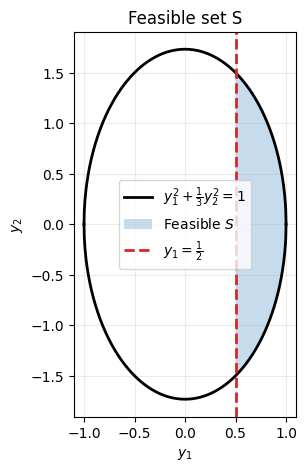

In [2]:
# (a) Plot S
plot_S()


In [3]:
# Quick verification: piecewise f(x) equals max_{y in S} x·y
max_abs_err, worst = verify_on_grid(m=161)
max_abs_err, worst


(1.3322676295501878e-15,
 (np.float64(1.7000000000000002),
  np.float64(-1.45),
  3.0327380368241506,
  3.032738036824149))

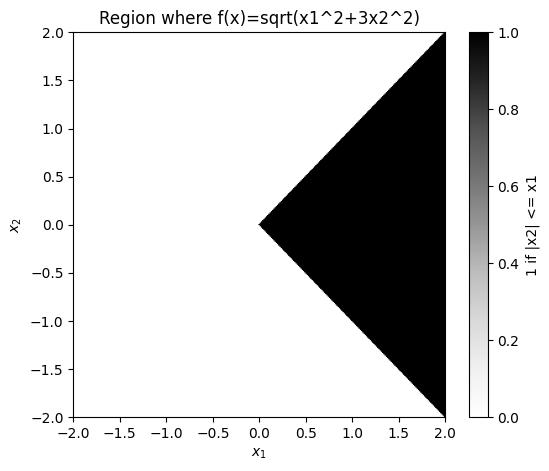

In [4]:
# Visualize which branch is active: |x2| <= x1 vs otherwise
m = 301
x1 = np.linspace(-2, 2, m)
x2 = np.linspace(-2, 2, m)
X1, X2 = np.meshgrid(x1, x2, indexing="xy")
mask = (np.abs(X2) <= X1)

plt.figure(figsize=(6, 5))
plt.imshow(mask.astype(float), origin="lower", extent=[x1.min(), x1.max(), x2.min(), x2.max()], aspect="auto", cmap="Greys")
plt.colorbar(label="1 if |x2| <= x1")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Region where f(x)=sqrt(x1^2+3x2^2)")
plt.show()
